# Root-Cause Analysis

## Top Sensors to Inspect

`sensor_059` is the top root-cause candidate. It has the strongest composite evidence across SHAP attribution, fail/pass attribution lift, and SPC flag behavior. The strongest composite candidates are `sensor_059`, `sensor_033`, `sensor_103`, `sensor_031`, and `sensor_021`. These sensors form the first inspection set for engineering follow-up.

## Data and Model Context

The analysis uses the selected model from notebook 04 (`models/selected_model.joblib`, a tuned random forest classifier) and the raw train/test splits. The test set contains 236 wafers; the pipeline consumes all 590 raw sensor columns and retains 242 of them inside its `SecomPreprocessor` step. Notebook 04 showed limited precision and high recall at the cost-tuned threshold, so the ranked sensors below support engineering review rather than automatic process changes.

In [1]:
from __future__ import annotations

import contextlib
import io
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from yield_risk.config import load_config
from yield_risk.explainability import compute_shap_values, global_feature_importance, save_shap_values
from yield_risk.root_cause import fail_shap_lift, rank_root_cause_candidates, spc_flag_rate

In [2]:
cfg = load_config(ROOT / "configs" / "config.yaml")

model_path = ROOT / "models" / "selected_model.joblib"
train_path = ROOT / "data" / "splits" / "train.csv"
test_path = ROOT / "data" / "splits" / "test.csv"

required_paths = [model_path, train_path, test_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Model and split data artifacts are required. Missing: "
        + ", ".join(str(path) for path in missing_paths)
    )

pipeline = joblib.load(model_path)
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# The pipeline carries its own SecomPreprocessor, so it consumes the raw
# sensor columns directly; feature selection and imputation happen inside.
sensor_cols = [column for column in test.columns if column.startswith("sensor_")]
if not sensor_cols:
    raise ValueError("No sensor_* columns found in split test data.")

X_train = train[sensor_cols]
X_test = test[sensor_cols]
y_test = test["label"].to_numpy()

print(f"Loaded selected model: {model_path}")
print(f"Classifier: {type(pipeline.named_steps['classifier']).__name__}")
print(
    f"Train rows: {len(train):,}; test rows: {len(test):,}; "
    f"raw sensors: {len(sensor_cols):,}"
)

Loaded selected model: C:\Users\Virgil\Code\semiconductor-yield-root-cause\models\selected_model.joblib
Classifier: RandomForestClassifier
Train rows: 1,331; test rows: 236; raw sensors: 590


## Explanation Signals

Three signals are combined for each sensor: mean absolute SHAP value, fail/pass SHAP lift, and SPC flag rate. Mean absolute SHAP measures how strongly the model uses a sensor overall. SHAP lift measures whether attribution differs between failing and passing wafers. SPC flag rate measures how often the sensor falls outside a mean plus or minus three-sigma band whose control limits are set from the stable training pass population, so a broad shift in the held-out batch cannot mask its own excursion.

The composite score emphasizes sensors that are important to the model, differ by outcome class, and show some statistical process-control abnormality in the held-out data.

In [3]:
shap_stdout = io.StringIO()
with contextlib.redirect_stdout(shap_stdout), contextlib.redirect_stderr(shap_stdout):
    explanations = compute_shap_values(pipeline, X_train, X_test)
global_importance = global_feature_importance(explanations)
# SPC limits come from the stable training pass population (label == 0) so a
# broad test-batch excursion cannot self-normalise its own flag rate.
train_pass = train[train["label"] == 0]
flag_rates = spc_flag_rate(test, sensor_cols, reference=train_pass)
shap_lift = fail_shap_lift(explanations, y_test)
candidates = rank_root_cause_candidates(global_importance, shap_lift, flag_rates)

print(
    f"Computed SHAP explanations for {len(X_test):,} test rows "
    f"and {len(sensor_cols):,} sensor features."
)
print(
    "Composite ranking combines mean absolute SHAP, fail/pass SHAP lift, "
    "and SPC flag rate."
)
candidates.head(15)

Computed SHAP explanations for 236 test rows and 590 sensor features.
Composite ranking combines mean absolute SHAP, fail/pass SHAP lift, and SPC flag rate.


,sensor,mean_abs_shap,shap_lift,spc_flag_rate,composite_score
0,sensor_059,0.010310,0.018617,0.000000,0.800000
1,sensor_033,0.007462,0.003970,0.016949,0.487369
2,sensor_103,0.006186,0.002544,0.004237,0.356394
3,sensor_031,0.005764,-0.001693,0.000000,0.306826
4,sensor_021,0.003928,0.001394,0.021186,0.289893
5,sensor_064,0.003235,0.003524,0.016949,0.275226
6,sensor_205,0.003759,0.003915,0.004237,0.260749
7,sensor_129,0.004442,0.002506,0.000000,0.255821
8,sensor_065,0.002691,0.002229,0.021186,0.243334
9,sensor_433,0.001051,0.000320,0.050847,0.240759


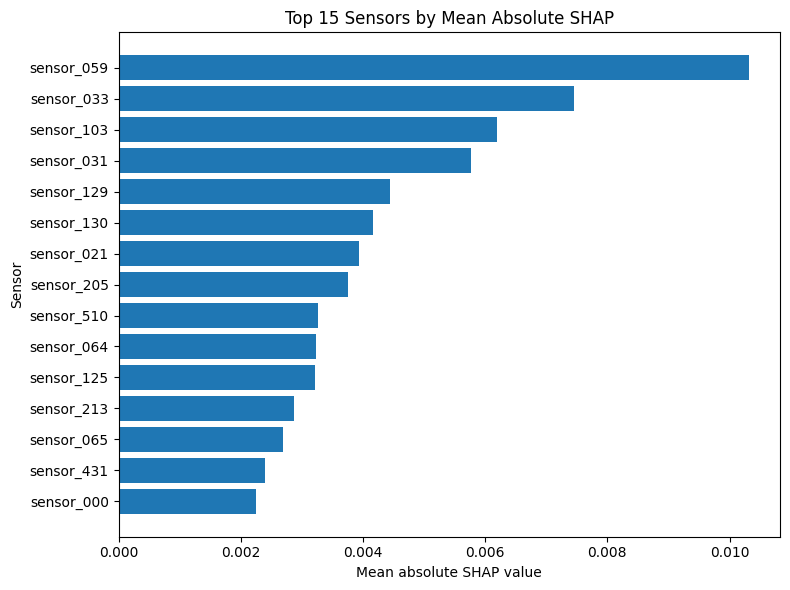

In [4]:
top_n = 15
top_importance = global_importance.head(top_n).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_importance["feature"], top_importance["mean_abs_shap"])
ax.set_title(f"Top {top_n} Sensors by Mean Absolute SHAP")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("Sensor")
plt.tight_layout()

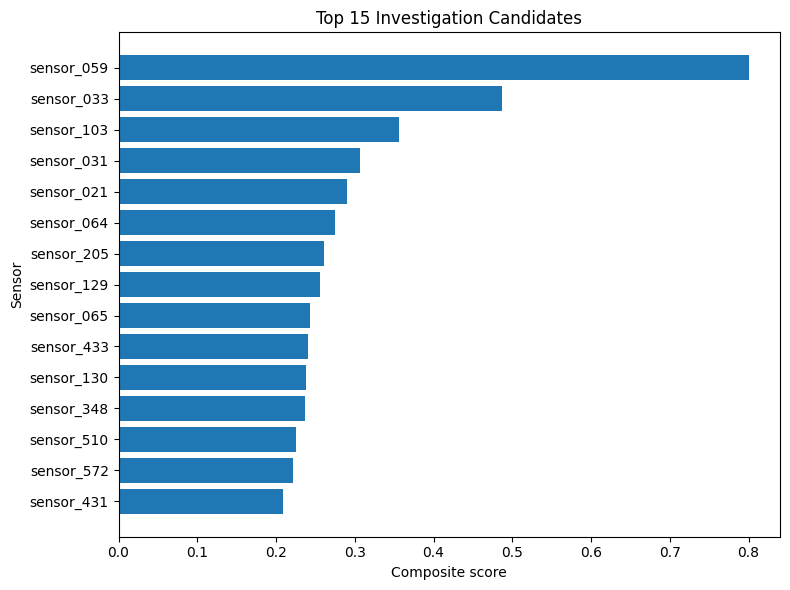

In [5]:
top_candidates = candidates.head(top_n).sort_values("composite_score")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_candidates["sensor"], top_candidates["composite_score"])
ax.set_title(f"Top {top_n} Investigation Candidates")
ax.set_xlabel("Composite score")
ax.set_ylabel("Sensor")
plt.tight_layout()

## Distribution Review

The top-ranked sensors show different patterns. `sensor_059` leads the composite score by a wide margin, carrying both the single largest mean absolute SHAP value (~0.010) and the largest positive fail/pass SHAP lift (~0.019), alongside a ~0% SPC flag rate against the training-pass control limits — its lead rests on model attribution rather than process-control excursions. `sensor_033` places a clear second on the second-largest mean absolute SHAP value but a much smaller lift, and `sensor_103` follows on a similar profile. `sensor_031` and `sensor_021` round out the top set on moderate attribution and SPC flagging (`sensor_031` despite a slightly negative lift). The distribution plots compare pass and fail density directly, exposing whether these rankings reflect broad separation or a small number of tail observations.

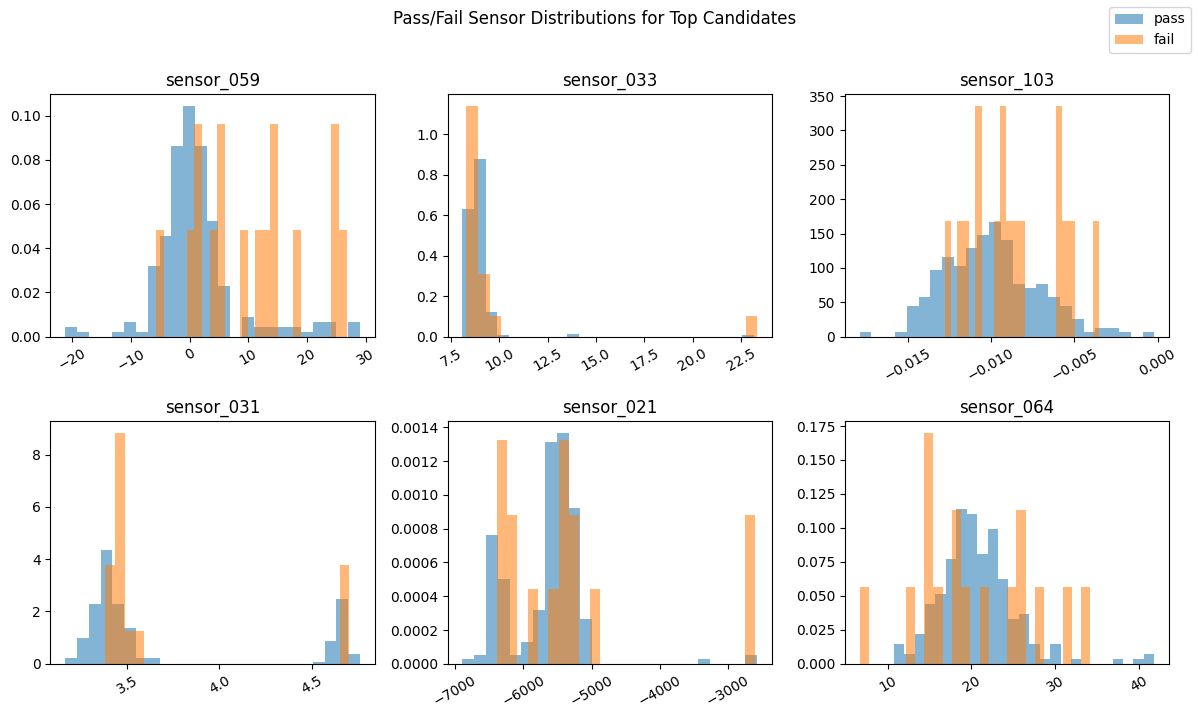

In [6]:
sensors_to_plot = candidates.head(6)["sensor"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, sensor in zip(axes.ravel(), sensors_to_plot, strict=False):
    passing = test.loc[test["label"] == 0, sensor].dropna()
    failing = test.loc[test["label"] == 1, sensor].dropna()
    ax.hist(passing, bins=25, alpha=0.55, label="pass", density=True)
    ax.hist(failing, bins=25, alpha=0.55, label="fail", density=True)
    ax.set_title(sensor)
    ax.tick_params(axis="x", labelrotation=30)

for ax in axes.ravel()[len(sensors_to_plot):]:
    ax.axis("off")

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Pass/Fail Sensor Distributions for Top Candidates", y=1.02)
plt.tight_layout()

## Persisted Review Artifacts

The SHAP values, global SHAP importance, and ranked root-cause candidate table are stored in `reports/`. These artifacts preserve the exact attribution results used in this report and provide the tabular inputs for follow-up process analysis.

In [7]:
reports_dir = ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

save_shap_values(explanations, reports_dir / "shap_values.npz")
global_importance.to_csv(reports_dir / "shap_global_importance.csv", index=False)
candidates.to_csv(reports_dir / "root_cause_candidates.csv", index=False)

print(f"Saved review artifacts to {reports_dir}")

Saved review artifacts to C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports


## What to Check Next

The root-cause analysis is consistent with the modeling limits observed in notebook 04, and it agrees with that notebook's model-based importance from a separate importance method. The random forest impurity importance and the SHAP global ranking both place `sensor_059`, `sensor_033`, and `sensor_103` at the very top, with `sensor_031` and `sensor_129` also appearing high in both views. That cross-method agreement strengthens their value as the first sensors to inspect.

The next engineering step is to map `sensor_059`, `sensor_033`, `sensor_103`, `sensor_031`, and `sensor_021` to process step, tool, chamber, recipe, lot, and maintenance context. Because SECOM sensor IDs are anonymous and the label is binary pass/fail, process changes should wait until the leading sensor set is connected to fab context and checked for persistence across time, lots, tools, or chambers.